In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [12]:
# Graph visualization code adopted from Andrej Karpathy's micrograd lecture jupyternotebook:
# https://github.com/karpathy/nn-zero-to-hero/tree/master/lectures/micrograd

# NOTE: graphviz is a python wrapper on top of graphviz's dot binary which needs to be installed on your machine.
# I used brew install graphviz for this.

from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)

    # create all the nodes in the graph -- records and ops
    # add all op->record edges in the graph
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect the op node to it
            dot.edge(uid + n._op, uid)

    # add all the record->op edges in the graph
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [ ]:
class Value:
    def __init__(self, data, predecessors=(), label="", op=""):
        self.data = data
        self.label = label  # object label for viz
        self._op = op  # operation that created the object
        self._prev = predecessors  # who created the object using the operation
        self.grad = 0

    # __repr__ --> object or print(object) both work
    # __str__ --> only print(object) works
    def __repr__(self):
        return f"Value({self.data})"

    # called when "+" is used. Eg: obj1 + obj2
    def __add__(self, other):
        out = Value(self.data + other.data, predecessors=(self, other), op="+")
        return out

    # called when "*" is used. Eg: obj1 * obj2
    def __mul__(self, other):
        out = Value(self.data * other.data, predecessors=(self, other), op="*")
        return out

    # called when "**" is used. Eg: obj1 ** integer
    def __pow__(self, other: int):
        out = Value(self.data**other, predecessors=(self,), op=f"**{other}")
        return out

    # called when "/" is used. Eg: obj1/obj2
    # makes use of the __pow__ and __mul__ methods
    def __truediv__(self, other):
        return self * other**-1

    # no dunder for exponent
    def exp(self):
        out = Value(math.exp(self.data), predecessors=(self,), op="exp")
        return out

In [34]:
a = Value(2)
a.label = "a"
b = Value(3)
b.label = "b"
c = a + b
c.label = "c"
d = Value(4)
d.label = "d"
e = c * d
e.label = "e"
f = e**2
f.label = "f"
g = Value(50)
g.label = "g"
h = f / g
h.label = "h"
i = h.exp()
i.label = "i"

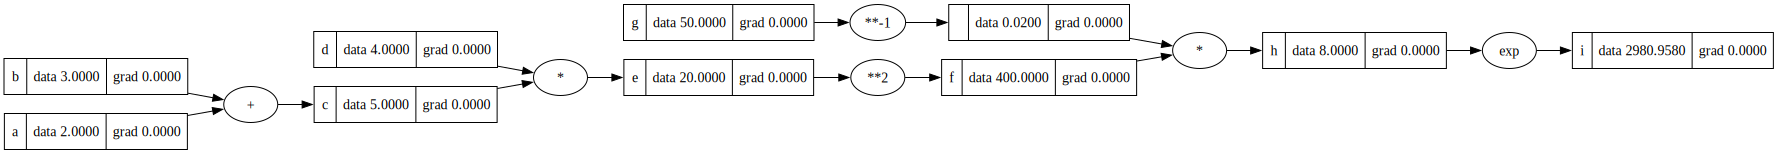

In [36]:
draw_dot(i)